# 01 -- Signal processing fundamentals: from waveform to spectrogram (and beyond)

Every model in this project (except the raw waveform itself) sees a
**spectrogram**, not the audio. This notebook builds that intuition from
scratch: what a spectrogram actually is, why the parameters you choose
matter for underwater bioacoustic signals specifically, and how
passive-sonar practitioners adapt these choices (linear vs. mel frequency
axis, window length, etc.) for their signals rather than borrowing
speech-processing defaults blindly.

It then goes one step further than a plain spectrogram, into two classic
passive-sonar analysis techniques -- **DEMON** and **matched filtering**
-- applied to species that produce literal biosonar click trains
(sperm whales, dolphins).

In [1]:
import os
import subprocess
import sys
import importlib.util

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # 1. Mount Drive and locate the project. Upload src/, configs/,
    #    pyproject.toml, requirements.txt to this path in My Drive first --
    #    NOT the multi-GB Watkins/ or results/ folders, those are handled
    #    separately below.
    from google.colab import drive
    drive.mount("/content/drive")

    PROJECT_DRIVE_PATH = "/content/drive/MyDrive/MarineMammals"  # <-- edit if you used a different path
    if not os.path.exists(f"{PROJECT_DRIVE_PATH}/src/watkins"):
        raise FileNotFoundError(
            f"Expected the project's src/ folder at {PROJECT_DRIVE_PATH}/src on Google Drive.\n"
            "Upload src/, configs/, pyproject.toml, and requirements.txt there "
            "(skip the multi-GB Watkins/ and results/ folders), or edit "
            "PROJECT_DRIVE_PATH above to match where you put them."
        )
    sys.path.insert(0, f"{PROJECT_DRIVE_PATH}/src")

    # 2. Install whatever Colab's base image doesn't already have. Deliberately
    #    does NOT touch torch/torchaudio/torchvision -- Colab's preinstalled
    #    versions are already matched to its GPU + CUDA build, and reinstalling
    #    this project's CPU-only wheels here would silently disable the GPU.
    needed = ["transformers", "timm", "soundfile", "datasets", "huggingface_hub", "pyarrow"]
    missing = [pkg for pkg in needed if importlib.util.find_spec(pkg) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

    # 3. Data goes on fast local/ephemeral disk (re-derivable from the public
    #    Hugging Face source, no reason to pay Drive's slow random-I/O tax on
    #    thousands of per-epoch file reads); results go on Drive so trained
    #    checkpoints/metrics survive a runtime disconnect.
    os.environ["WATKINS_DATA_ROOT"] = "/content/watkins_data"
    os.environ["WATKINS_RESULTS_ROOT"] = f"{PROJECT_DRIVE_PATH}/results"

    from watkins.data import DATA_ROOT
    if not (DATA_ROOT / "manifest.csv").exists():
        print("Materializing the Watkins dataset locally -- one-time per Colab runtime, ~10-15 min...")
        subprocess.run([sys.executable, "-m", "watkins.prepare_data"], check=True)
else:
    sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt
import torch
import soundfile as sf
from IPython.display import Audio, display

from watkins.data import load_manifest, CLASS_INFO, CLASS_IDS
from watkins.features import (
    LogMelSpectrogram,
    lofar_gram,
    demon_envelope,
    demon_spectrum,
    matched_filter,
    matched_filter_bank,
    detect_peaks,
    average_pulse_template,
    pulse_train_stats,
    MIN_DETECTIONS,
)


## 1. The waveform

A handful of species, chosen to span the acoustic diversity in this
dataset: a tonal baleen-whale moan (humpback), a loud, common odontocete
(killer whale), a classic echolocation-click user (sperm whale), and a
pinniped (walrus, which produces knocks/clicks of its own). Even a 3-4
second clip is tens of thousands of samples -- far too many to reason
about individually, which is exactly why we need a time-frequency
representation.

Each clip is named explicitly by its Watkins record number rather than
taken as "whichever clip of this species comes first in the manifest",
and there is an audio player under the figure for each one. Both of
those matter more than they look: a lot of clips in this database are
distant, noisy, or barely contain the call the label promises, and every
later section here asks you to *look for a specific structure* in these
same clips. If the example is a poor one, the structure isn't there to
find and the lesson silently teaches the wrong thing. Listen first.

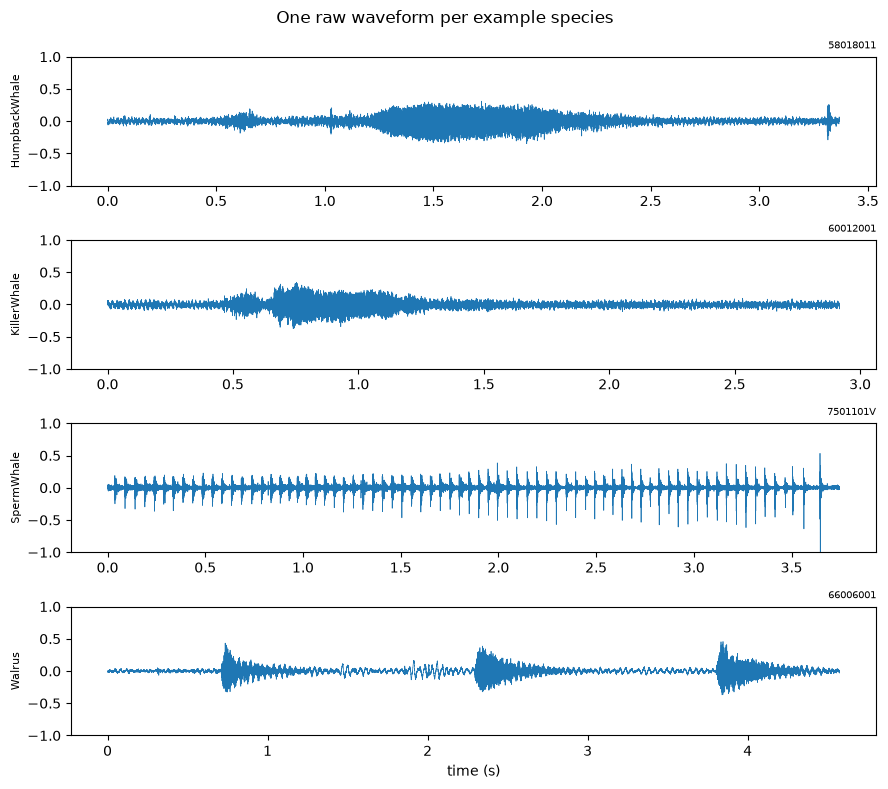

HumpbackWhale  --  58018011, 3.4s


KillerWhale  --  60012001, 2.9s


SpermWhale  --  7501101V, 3.7s


Walrus  --  66006001, 4.6s


In [2]:
manifest = load_manifest()
by_class = {c: [clip for clip in manifest if clip.label == c] for c in CLASS_IDS}
by_record = {clip.record_number: clip for clip in manifest}

# Chosen by listening and by checking the structure each later section
# claims to show is actually present -- not by manifest order. The first
# HumpbackWhale and SpermWhale clips in the manifest are both faint,
# noisy recordings: the humpback shows almost no harmonic stack for
# section 3 to point at, and the sperm whale's clicks barely rise above
# the noise floor for section 5's DEMON analysis.
EXAMPLE_RECORDS = {
    12: "58018011",  # HumpbackWhale -- moan with a clear ~0.5kHz fundamental + harmonics
    22: "60012001",  # KillerWhale   -- frequency-modulated whistles, strong harmonics
    51: "7501101V",  # SpermWhale    -- steady echolocation click train, ~20 clicks/s
    21: "66006001",  # Walrus        -- three loud knocks, each with its own harmonic stack
}
examples = {cid: by_record[rec] for cid, rec in EXAMPLE_RECORDS.items()}

fig, axes = plt.subplots(len(examples), 1, figsize=(9, 8), sharex=False)
for ax, (cid, clip) in zip(axes, examples.items()):
    y, sr = sf.read(clip.path)
    t = np.arange(len(y)) / sr
    ax.plot(t, y, linewidth=0.5)
    ax.set_ylabel(CLASS_INFO[cid]["display_name"], fontsize=8)
    ax.set_title(clip.record_number, fontsize=7, loc="right")
    ax.set_ylim(-1, 1)
axes[-1].set_xlabel("time (s)")
fig.suptitle("One raw waveform per example species")
plt.tight_layout()
plt.show()

for cid, clip in examples.items():
    y, sr = sf.read(clip.path)
    print(f"{CLASS_INFO[cid]['display_name']}  --  {clip.record_number}, {len(y) / sr:.1f}s")
    display(Audio(y, rate=sr))


## 2. STFT -> spectrogram: the core transform

A spectrogram slides a short analysis window across the waveform,
computes a Fourier transform inside each window (the Short-Time Fourier
Transform, STFT), and stacks the resulting frequency-magnitude vectors
side by side. Two parameters control everything:

- **window/FFT length** (`n_fft`): longer windows -> finer *frequency*
  resolution, coarser *time* resolution (a tonal's frequency becomes more
  precise, but you blur over fast transients).
- **hop length**: how far the window slides between frames. Smaller hop
  -> more overlap -> smoother spectrogram, more compute.

This is a real trade-off, not a knob to max out: a baleen whale's sustained
tonal moan benefits from frequency resolution, but an echolocation click
train is broadband and time-localized -- exactly the opposite need.
`LogMelSpectrogram` in `watkins/features.py` defaults to a 25ms window /
10ms hop (speech defaults) -- let's see whether that's actually a good
choice for a tonal call.

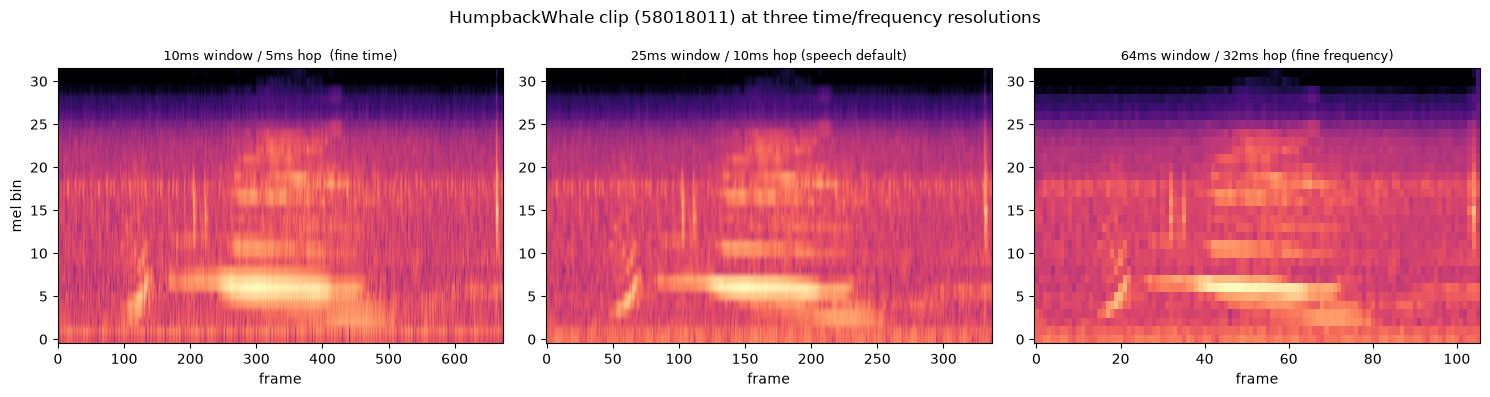

In [3]:
clip = examples[12]  # HumpbackWhale -- sustained tonal moan
y, sr = sf.read(clip.path)
wav = torch.from_numpy(y.astype(np.float32)).unsqueeze(0)

configs = [
    ("10ms window / 5ms hop  (fine time)",   160, 80),
    ("25ms window / 10ms hop (speech default)", 400, 160),
    ("64ms window / 32ms hop (fine frequency)", 1024, 512),
]

fig, axes = plt.subplots(1, len(configs), figsize=(15, 4))
for ax, (title, n_fft, hop) in zip(axes, configs):
    feat = LogMelSpectrogram(n_fft=n_fft, hop_length=hop, n_mels=32, per_instance_normalize=False)
    spec = feat(wav).squeeze(0).numpy()
    ax.imshow(spec, aspect="auto", origin="lower", cmap="magma")
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("frame")
ax0 = axes[0]; ax0.set_ylabel("mel bin")
fig.suptitle(f"HumpbackWhale clip ({clip.record_number}) at three time/frequency resolutions")
plt.tight_layout()
plt.show()


## 3. Mel scale vs. linear frequency: why passive sonar often prefers linear

The mel scale compresses frequency the way human hearing does -- lots of
resolution at low frequencies, very little at high ones. That's a
reasonable prior for speech. For a tonal call it's a more debatable
choice: harmonic components of a moan or whistle sit at fixed physical
frequencies, and mel warping smears them differently depending on where
they land, whereas a **LOFARgram** (LOw Frequency Analysis and
Recording) keeps a **linear** frequency axis specifically so a tonal
stays at a consistent row/position across recordings and is easy to
track by eye or algorithm.

Compare the two directly on the same clip:

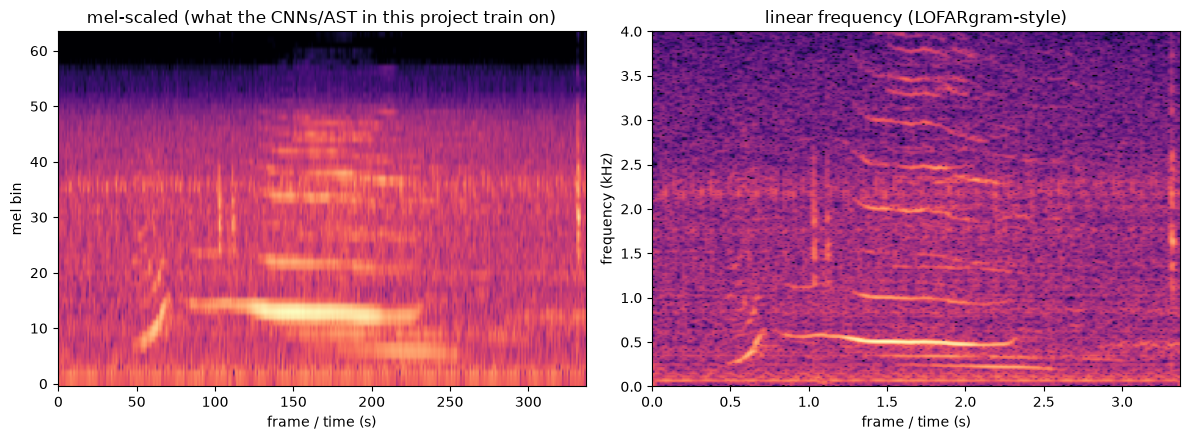

In [4]:
mel_feat = LogMelSpectrogram(n_mels=64, per_instance_normalize=False)
mel_spec = mel_feat(wav).squeeze(0).numpy()
lofar = lofar_gram(wav, n_fft=1024, hop_length=256).numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].imshow(mel_spec, aspect="auto", origin="lower", cmap="magma")
axes[0].set_title("mel-scaled (what the CNNs/AST in this project train on)")
axes[0].set_ylabel("mel bin")
im = axes[1].imshow(lofar, aspect="auto", origin="lower", cmap="magma",
                     extent=[0, len(y) / sr, 0, sr / 2 / 1000])
axes[1].set_title("linear frequency (LOFARgram-style)")
axes[1].set_ylabel("frequency (kHz)")
axes[1].set_ylim(0, 4)  # most humpback call energy is below ~4kHz -- zoom in
for ax in axes:
    ax.set_xlabel("frame / time (s)")
plt.tight_layout()
plt.show()


Look for near-horizontal bright stripes in the linear-frequency plot --
those are tonal harmonics of the call's fundamental frequency, the same
way a musical note has overtones. This clip has a fundamental a little
above 0.5kHz with several overtones stacked above it. This is the
classic starting point for classical (pre-deep-learning) passive-sonar
target classification: extract tonal frequencies and track them, rather
than feed a whole image to a classifier. Deep models trained on the mel
spectrogram *can* still pick up on this structure -- one open question
for you to explore in notebook 05's error analysis is whether
misclassifications correlate with clips where tonal harmonics are weak
or absent.

## 4. Per-instance normalization

`LogMelSpectrogram` z-score normalizes each spectrogram independently by
default (subtract its own mean, divide by its own std). This dataset's
clips vary enormously in loudness (close vs. distant recordings, loud vs.
quiet species) -- without normalization, that loudness difference alone
would let a lazy model "solve" much of the task by intensity, rather than
by shape. Find the loudest and quietest clip in a small sample and
compare.

**One thing to get right before reading the figure.** Z-scoring is an
*affine* map: every pixel becomes `(x - mean) / std`, with one mean and
one std for the whole image. Affine maps preserve order and relative
spacing, so if you let `imshow` autoscale each panel to its own
min/max -- which is what it does by default -- the raw and the normalized
panel come out **pixel-for-pixel identical**. That is not a bug and it is
not evidence that normalization did nothing; it is evidence that
autoscaling has thrown away the only thing that changed. Normalization
does not alter the shape inside one spectrogram at all. What it alters is
where that shape sits on an *absolute* intensity scale, which only
becomes visible when two clips share one colour scale.

So the figure below pins `vmin`/`vmax` per column across both rows: the
raw column on an absolute dB scale, the normalized column on an absolute
"standard deviations from this clip's own mean" scale. Read it column by
column, comparing the two rows.

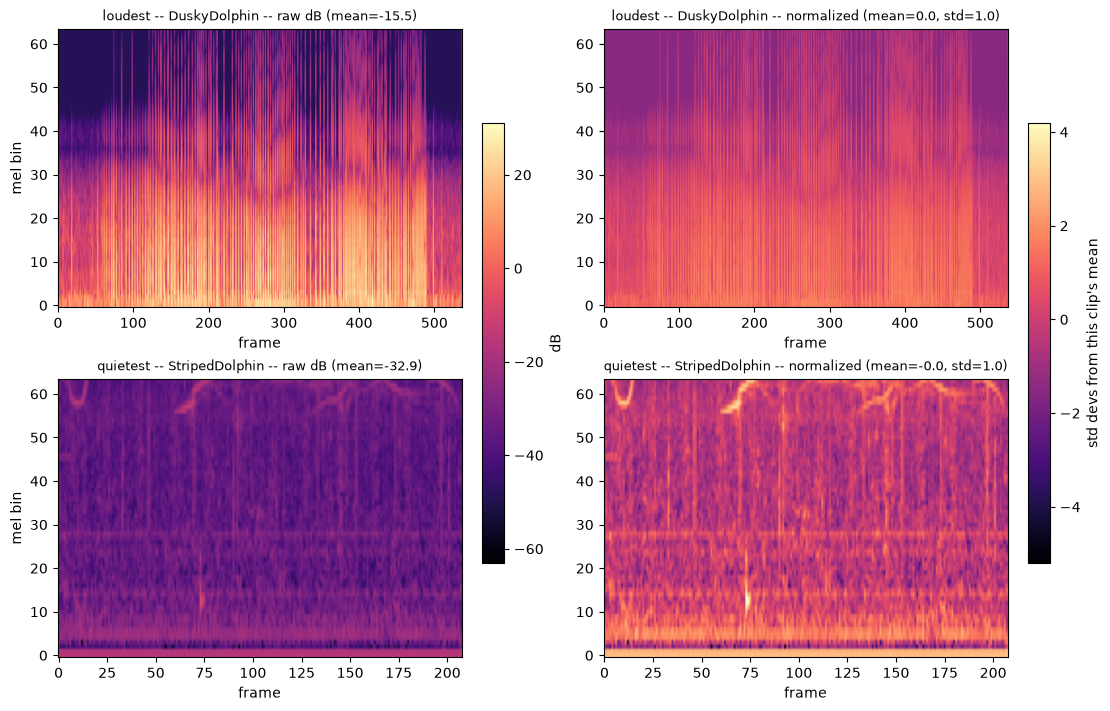

RMS ratio loudest:quietest = 64:1

loudest   DuskyDolphin           raw dB mean   -15.5  ->  normalized mean  0.00 std 1.00
quietest  StripedDolphin         raw dB mean   -32.9  ->  normalized mean -0.00 std 1.00


In [5]:
rng = np.random.default_rng(0)
sample = rng.choice(manifest, size=200, replace=False)
rms_vals = []
for clip in sample:
    y_s, sr_s = sf.read(clip.path)
    rms_vals.append(np.sqrt(np.mean(y_s.astype(np.float64) ** 2)))
rms_vals = np.array(rms_vals)
loud_clip, quiet_clip = sample[rms_vals.argmax()], sample[rms_vals.argmin()]

feat_raw = LogMelSpectrogram(per_instance_normalize=False)
feat_norm = LogMelSpectrogram(per_instance_normalize=True)

specs = {}
for role, clip in [("loudest", loud_clip), ("quietest", quiet_clip)]:
    y_c, sr_c = sf.read(clip.path)
    w = torch.from_numpy(y_c.astype(np.float32)).unsqueeze(0)
    specs[role] = (clip, feat_raw(w).squeeze(0).numpy(), feat_norm(w).squeeze(0).numpy())

# One colour scale per column, shared by both rows -- the whole point of
# the figure. Left to autoscale, each panel would be stretched to its own
# min/max and the raw and normalized versions of the same clip would come
# out identical images (z-scoring is affine; see the text above).
raw_lim = (min(s[1].min() for s in specs.values()), max(s[1].max() for s in specs.values()))
norm_lim = (min(s[2].min() for s in specs.values()), max(s[2].max() for s in specs.values()))

fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
for row, (role, (clip, raw, norm)) in enumerate(specs.items()):
    label = CLASS_INFO[clip.label]["display_name"]
    im_raw = axes[row, 0].imshow(raw, aspect="auto", origin="lower", cmap="magma",
                                 vmin=raw_lim[0], vmax=raw_lim[1])
    axes[row, 0].set_title(f"{role} -- {label} -- raw dB (mean={raw.mean():.1f})", fontsize=9)
    im_norm = axes[row, 1].imshow(norm, aspect="auto", origin="lower", cmap="magma",
                                  vmin=norm_lim[0], vmax=norm_lim[1])
    axes[row, 1].set_title(f"{role} -- {label} -- normalized "
                           f"(mean={norm.mean():.1f}, std={norm.std():.1f})", fontsize=9)
    axes[row, 0].set_ylabel("mel bin")
    axes[row, 1].set_xlabel("frame")
    axes[row, 0].set_xlabel("frame")
fig.colorbar(im_raw, ax=axes[:, 0], label="dB", shrink=0.7)
fig.colorbar(im_norm, ax=axes[:, 1], label="std devs from this clip's mean", shrink=0.7)
plt.show()

print(f"RMS ratio loudest:quietest = {rms_vals.max() / rms_vals.min():.0f}:1\n")
for role, (clip, raw, norm) in specs.items():
    print(f"{role:9s} {CLASS_INFO[clip.label]['display_name']:22s} "
          f"raw dB mean {raw.mean():7.1f}  ->  normalized mean {norm.mean():5.2f} std {norm.std():4.2f}")


## 5. Beyond the spectrogram: DEMON analysis

A spectrogram of a click train (dolphin echolocation, sperm whale codas)
shows a smear of broadband energy at every click -- it doesn't directly
tell you *how often* the clicks repeat, which is often the most
diagnostic single number for that kind of call. **DEMON** (DEModulation
Of Envelope on Noise) is the classic passive-sonar technique for exactly
this: high-pass the signal, rectify it into an envelope, low-pass that
envelope, then take the FFT of *the envelope itself*. A periodic pulse
train produces a sharp peak in this "spectrum of the envelope" at its
repetition rate -- originally used to read a ship's propeller shaft/blade
rate off cavitation noise, and directly reusable here to read an
echolocating animal's click-repetition rate.

Two practical points, because DEMON is easy to run and get nothing out
of:

- **Frequency resolution is 1/duration, and it has to come from the whole
  clip.** Click rates of interest are tens of Hz, so the bins have to be
  a fraction of a Hz wide to resolve anything. A 3-4 second clip gives
  ~0.3Hz bins -- but only if the FFT runs over the entire envelope.
  Zero-padding to a fixed `n_fft` at the 16kHz audio rate does the
  opposite: it truncates the envelope to its first fraction of a second
  and spends almost every bin on frequencies far above any possible
  repetition rate. `demon_spectrum` therefore decimates the envelope to
  1kHz first and then transforms all of it.
- **Everything hangs on the clip actually containing a click train.** A
  DEMON spectrum of a distant, low-SNR recording is a flat noise floor
  with one or two accidental bumps in it, which is very easy to misread
  as a weak repetition rate. Play the clips below: you should be able to
  *hear* the sperm whale's clicks as a rattle at a steady rate.

The plot shows both stages, so the peak can be checked against something
countable: the envelope on top (the pulse train itself) and its spectrum
underneath.

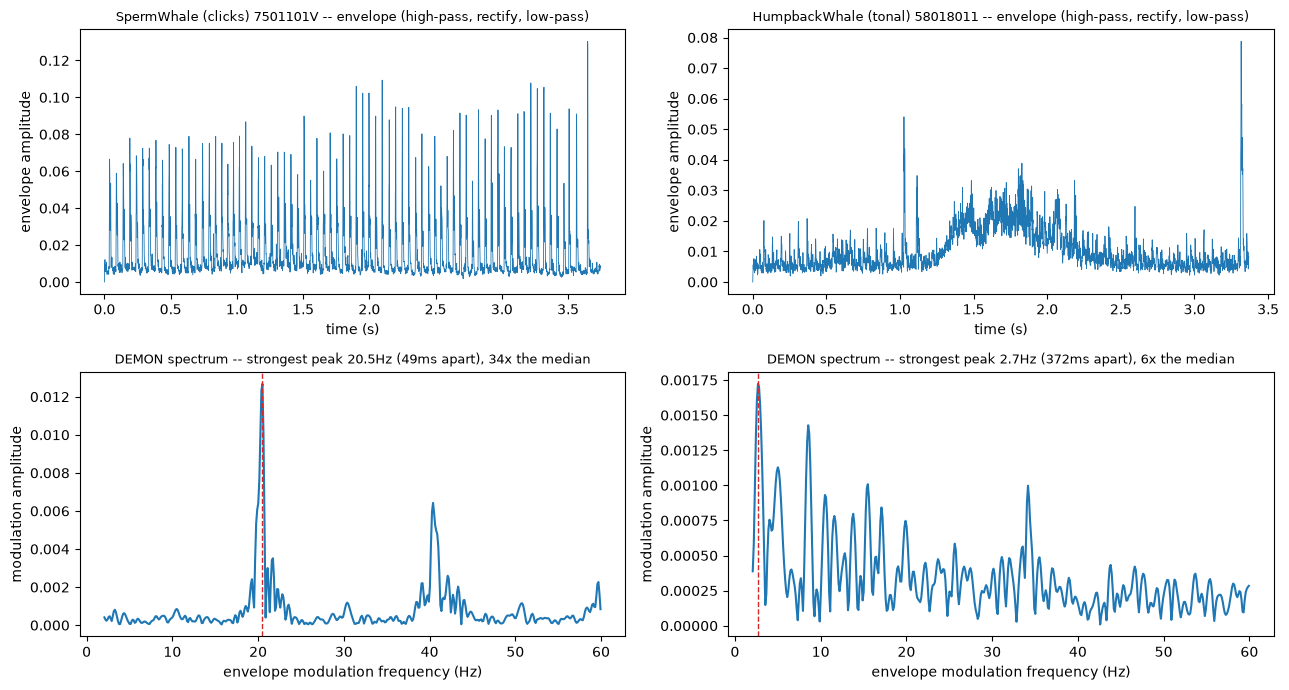

SpermWhale (clicks)  --  7501101V, 3.7s


HumpbackWhale (tonal)  --  58018011, 3.4s


In [6]:
demon_examples = [
    (examples[51], "SpermWhale (clicks)"),
    (examples[12], "HumpbackWhale (tonal)"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for col, (clip, title) in enumerate(demon_examples):
    y_c, sr_c = sf.read(clip.path)
    w = torch.from_numpy(y_c.astype(np.float32)).unsqueeze(0)

    # Top row: the envelope DEMON actually measures. Countable by eye.
    env, env_rate = demon_envelope(w, sample_rate=sr_c)
    axes[0, col].plot(np.arange(len(env)) / env_rate, env.numpy(), linewidth=0.6)
    axes[0, col].set_title(f"{title} {clip.record_number} -- envelope "
                           f"(high-pass, rectify, low-pass)", fontsize=9)
    axes[0, col].set_xlabel("time (s)")
    axes[0, col].set_ylabel("envelope amplitude")

    # Bottom row: its spectrum. Below ~2Hz is the residual DC skirt, not a
    # click rate -- no animal's click train is that slow in a 3-4s clip.
    freqs, mag = demon_spectrum(w, sample_rate=sr_c)
    keep = (freqs >= 2) & (freqs <= 60)
    f_keep, m_keep = freqs[keep].numpy(), mag[keep].numpy()
    peak_hz = f_keep[m_keep.argmax()]
    axes[1, col].plot(f_keep, m_keep)
    axes[1, col].axvline(peak_hz, color="tab:red", linestyle="--", linewidth=1)
    axes[1, col].set_title(f"DEMON spectrum -- strongest peak {peak_hz:.1f}Hz "
                           f"({1000 / peak_hz:.0f}ms apart), "
                           f"{m_keep.max() / np.median(m_keep):.0f}x the median", fontsize=9)
    axes[1, col].set_xlabel("envelope modulation frequency (Hz)")
    axes[1, col].set_ylabel("modulation amplitude")
plt.tight_layout()
plt.show()

for clip, title in demon_examples:
    y_c, sr_c = sf.read(clip.path)
    print(f"{title}  --  {clip.record_number}, {len(y_c) / sr_c:.1f}s")
    display(Audio(y_c, rate=sr_c))


The sperm whale's DEMON spectrum has a sharp, isolated peak around 20Hz
-- one click roughly every 50ms -- with a smaller copy of it near 41Hz,
the peak's second harmonic (a pulse train is not a sine wave, so it has
overtones in the envelope spectrum just as a musical note does in the
audio spectrum). Cross-check that against the envelope panel above it:
the clicks are individually visible there, and counting them over a
second gets you to the same number. That is the number you could not
read directly off a spectrogram.

The humpback panel is what "nothing to find" looks like: a noise floor a
few times its own median, with the largest bump sitting at the very left
edge where the residual DC skirt lives, and no harmonic above it. Note
that a bump *does* exist -- `argmax` always returns something. The
difference between a real rate and an accident of the noise floor is
peak sharpness, an isolated location away from DC, harmonics, and
agreement with the envelope you can see and the audio you can hear. A
single number reported without those checks is not evidence of anything.

## 6. Matched filtering: detecting a known target shape

The other classic sonar-analysis primitive is the **matched filter**:
slide a known reference template across a signal and measure the
correlation at every position. This is how you'd *detect and time-align*
a specific call, as opposed to classifying an already-isolated clip.

**What to correlate is the whole question.** The obvious choice --
slice a piece of raw waveform and cross-correlate it -- does not work
here, and the cell below runs it so you can see the failure rather than
take it on faith. A click's fine waveform structure is exactly the part
this pipeline destroys: resampling to 16kHz (`data.py`) throws away most
of the click's bandwidth, and what remains is coloured by whichever tape,
hydrophone and propagation path the recording came off. Two sperm whale
clicks from different tapes do not have the same waveform.

What *does* survive is the shape of the energy burst and, more
importantly, its timing. So we correlate in the **envelope domain** --
the same `demon_envelope` signal section 5 measured the rate of. The
template is an average of the strongest pulses in one clip
(`average_pulse_template`), not a single hand-picked one, so it carries
the common shape instead of one pulse's noise.

**And the statistic has to change too.** Peak correlation height is
useless here: a normalized correlation is a *shape* comparison, and a
walrus knock, a humpback song onset and a sperm whale click all look
like "a transient" once you are looking at a 1kHz envelope. What
distinguishes a click train is not that any one pulse matches, it is
that many matches arrive **at a regular spacing**. So the cell thresholds
the response into detections and reports two numbers:

- **CV of the gaps** between consecutive detections. Low = metronomic =
  a click train; high = scattered.
- **Fraction of detections landing on a real pulse** rather than in the
  quiet between pulses. A normalized correlation is scale-free, so it
  will fire happily on a wiggle in the noise floor -- and a train of
  *those* can be regular too. Without this second number, a low CV is
  not trustworthy.

Three test clips: two SpermWhale recordings that both contain real click
trains, and one HumpbackWhale. Note the tape IDs printed on the panels --
they matter more than you would expect, and the text after the figure
works out how much:

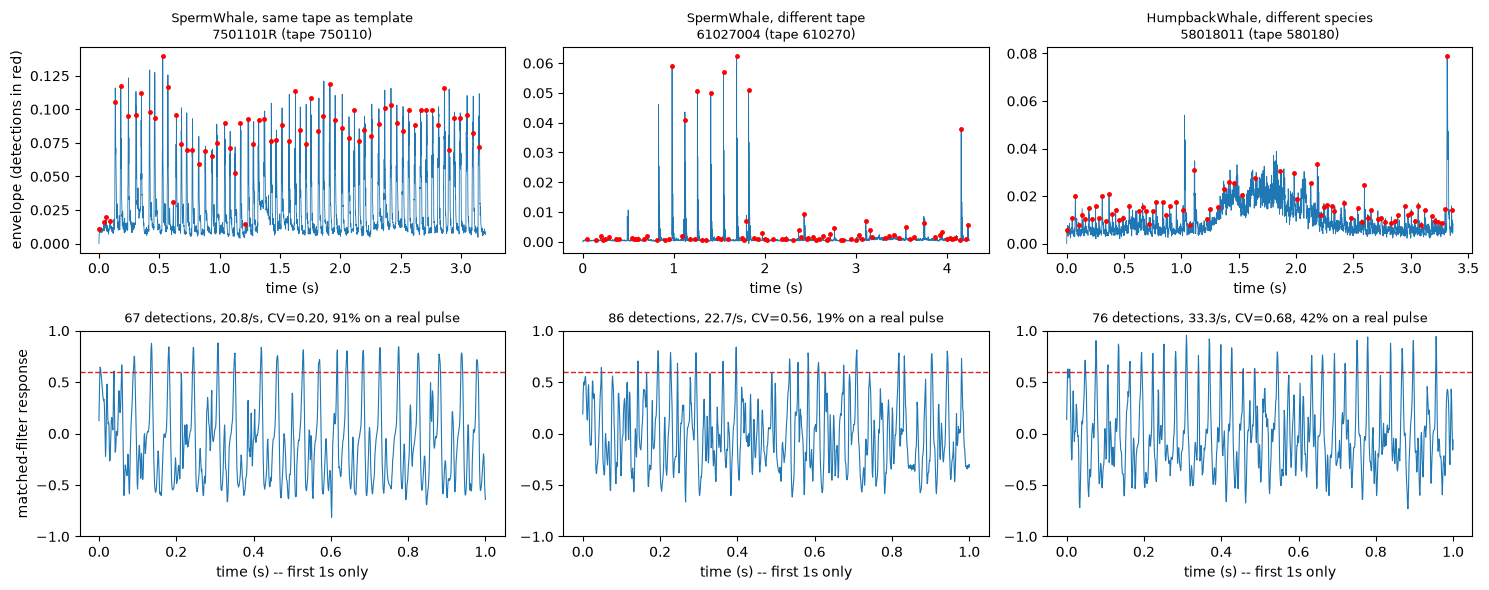

Peak correlation using a RAW WAVEFORM template (50ms centred on a click):
  SpermWhale, same tape as template    0.30


  SpermWhale, different tape           0.37
  HumpbackWhale, different species     0.29

-> the different-species clip scores level with the same-species ones.
   No threshold you could pick on this number separates them.


In [7]:
species_a, species_b = 51, 12  # SpermWhale, HumpbackWhale

TEMPLATE_RECORD = "7501101V"   # the click train section 5 measured at ~20.5Hz
DETECTION_THRESHOLD = 0.6      # on the normalized correlation, which runs 0..1
ZOOM_S = 1.0                   # the response panels are a solid band at full width

template_clip = by_record[TEMPLATE_RECORD]
y_t, sr_t = sf.read(template_clip.path)
wav_t = torch.from_numpy(y_t.astype(np.float32)).unsqueeze(0)
env_t, env_rate = demon_envelope(wav_t, sample_rate=sr_t)
template = average_pulse_template(env_t, env_rate)

test_clips = [
    ("SpermWhale, same tape as template", by_record["7501101R"]),
    ("SpermWhale, different tape",        by_record["61027004"]),
    ("HumpbackWhale, different species",  by_record["58018011"]),
]


def score(env, response, rate):
    """Threshold the response into detections and describe them.

    `pulse_train_stats` returns the pulse rate, the CV of the gaps between
    detections, and the share of detections landing on real energy rather
    than on the noise floor -- and returns NaN for all three when there are
    fewer than `MIN_DETECTIONS` (20) of them. Both statistics are averages
    over the detections and both drift *optimistic* as that count falls, so
    without the guard a 0.3s fragment outranks a real click train in any
    table sorted by CV. See the function's docstring for the measurement."""
    return pulse_train_stats(env, response, rate, DETECTION_THRESHOLD)


fig, axes = plt.subplots(2, len(test_clips), figsize=(15, 6))
for col, (label, clip) in enumerate(test_clips):
    y_c, sr_c = sf.read(clip.path)
    w = torch.from_numpy(y_c.astype(np.float32)).unsqueeze(0)
    env, rate = demon_envelope(w, sample_rate=sr_c)
    response = matched_filter(env.unsqueeze(0), template)
    stats = score(env, response, rate)
    det = stats.detections
    t = np.arange(len(env)) / rate

    axes[0, col].plot(t, env.numpy(), linewidth=0.6)
    axes[0, col].plot(det.numpy() / rate, env.numpy()[det.numpy()], "r.", markersize=5)
    axes[0, col].set_title(f"{label}\n{clip.record_number} (tape {clip.tape_id})", fontsize=9)
    axes[0, col].set_xlabel("time (s)")

    zoom = t <= ZOOM_S
    axes[1, col].plot(t[zoom], response.numpy()[zoom], linewidth=0.8)
    axes[1, col].axhline(DETECTION_THRESHOLD, color="tab:red", linestyle="--", linewidth=1)
    axes[1, col].set_title(f"{stats.n} detections, {stats.rate_hz:.1f}/s, CV={stats.cv:.2f}, "
                           f"{stats.on_pulse:.0%} on a real pulse", fontsize=9)
    axes[1, col].set_xlabel(f"time (s) -- first {ZOOM_S:g}s only")
    axes[1, col].set_ylim(-1, 1)
axes[0, 0].set_ylabel("envelope (detections in red)")
axes[1, 0].set_ylabel("matched-filter response")
plt.tight_layout()
plt.show()

# The obvious approach, for comparison: correlate raw waveforms instead of
# envelopes, using 50ms of waveform centred on the same click the envelope
# template was built around.
half = int(0.025 * sr_t)
centre = int(int(env_t.argmax()) / env_rate * sr_t)
start = min(max(0, centre - half), len(y_t) - 2 * half)
raw_template = torch.from_numpy(y_t[start:start + 2 * half].astype(np.float32))

print("Peak correlation using a RAW WAVEFORM template (50ms centred on a click):")
for label, clip in test_clips:
    y_c, sr_c = sf.read(clip.path)
    w = torch.from_numpy(y_c.astype(np.float32)).unsqueeze(0)
    print(f"  {label:36s} {matched_filter(w, raw_template).max():.2f}")
print("\n-> the different-species clip scores level with the same-species ones.")
print("   No threshold you could pick on this number separates them.")


Three things to take from that figure, in increasing order of how much
they should bother you.

**The envelope domain works, the raw waveform does not.** The printed
raw-waveform correlations are indistinguishable across all three clips --
the different-species clip scores level with the same-species ones. In
the envelope domain the detections on the first SpermWhale clip land on
the clicks, at a rate that matches section 5's DEMON peak, from a
completely independent computation.

**Amplitude is not in the response.** Look at the middle column's top
panel. The clip has a handful of loud clicks in its first two seconds and
then goes quiet, and the detector marks the quiet stretch just as
enthusiastically -- because a normalized correlation only asks about
shape. The "on a real pulse" percentage is what makes this visible; the
detection *count* and even the CV would not have.

**Most of the separation here is the recording, not the species.** The
three columns differ far more than "sperm whale vs. humpback" can
explain: two clips of the *same* species, both containing real click
trains, score CV 0.20/91% and 0.56/19%. Scored across all 1,184
SpermWhale clips this template can be run on, the median CV is 0.68 and
the interquartile range spans 0.56-0.79 -- the clip-to-clip spread
swamps every other effect in this section.

It is tempting to name the culprit "tape": clips sharing the template's
tape do score better (median CV 0.45, 78% on-pulse, n=59) than clips from
other tapes (0.69, 57%, n=1,125). But that comparison cannot separate
"the template matches this tape's recording conditions" from "this tape
simply contains cleaner click trains". The control is to swap the
template and re-score the same three tapes:

| template (its tape) | tape 750110 | tape 720090 | tape 935700 |
|---|---|---|---|
| `7501101V` (750110) | **0.45** | 0.62 | 0.70 |
| `72009005` (720090) | 0.44 | **0.61** | 0.72 |
| `93570011` (935700) | 0.69 | 0.67 | **0.73** |

(median CV of detection gaps; **bold** = template and clips share a tape)

The bold diagonal is not special. Tape 750110's clips score 0.45 with
their own tape's template and **0.44** with a foreign one, and template
`93570011` does *worst* on its own tape. What the table actually shows is
a column effect -- some tapes hold cleaner click trains -- and a row
effect -- some clips make better templates. Tape *matching* contributes
little on top of those.

So the honest summary is that this detector's performance is dominated by
which recordings you happened to pick, on both sides. That is a weaker
and less quotable claim than "it is a tape detector", and it is the one
the measurement supports. (An earlier version of this notebook made the
stronger claim from three hand-picked clips; exercise 5 below is what
caught it. Small samples plus a plausible story is exactly how a
confident wrong conclusion gets made -- including by whoever wrote the
notebook.)

## 7. A small template bank, not just one template

Section 6 ended on a problem: which single clip you build the template
from, and which clip you score, dominate the result. A template is one
animal, at one range, through one hydrophone, and you cannot tell from
the outside whether it is a good one.

The standard answer is not a better single template, it is **several** --
`matched_filter_bank` scores a signal against a list of templates and
takes the best match at each position, so a signal that resembles *any*
member counts as a match. If one template covers one corner of the
natural variation, a bank spanning several should cover more of it.

The bank below is four SpermWhale clips from four **different tapes**,
none of them a tape any test clip comes from. Keeping the bank clear of
the test clips' tapes costs nothing here and removes the one alternative
explanation that would be hardest to argue away afterwards -- the same
reason the splits in `data.py` are grouped by tape.

The cell scores each member individually as well as the bank, because
"bank vs. its first member" hides how much the answer swings depending on
which single clip you happen to start from. That swing is the thing
section 6 says you cannot predict in advance, so it is the thing worth
measuring.

bank:   93570011 (tape 935700),  72009005 (tape 720090),  9357300H (tape 935730),  9358400V (tape 935840)
tested: 7501101R (tape 750110),  61027004 (tape 610270),  58018011 (tape 580180)

pairwise template correlation: 0.60-0.92 (mean 0.73)

test clip                                   0011          9005          300H          400V          BANK
--------------------------------------------------------------------------------------------------------
SpermWhale, same tape as template     n=13   --    0.29  89%    0.94  85%    1.14  67%    0.29  75%
SpermWhale, different tape            0.52  16%    0.57  19%    0.58  18%    0.59  15%    0.45  12%
HumpbackWhale, different species      0.81  40%    0.89  44%    0.98  50%    0.67  36%    0.63  41%

(each cell: CV of detection gaps, then % of detections on a real pulse;
 'n=..' means fewer than 20 detections -- neither is estimable)


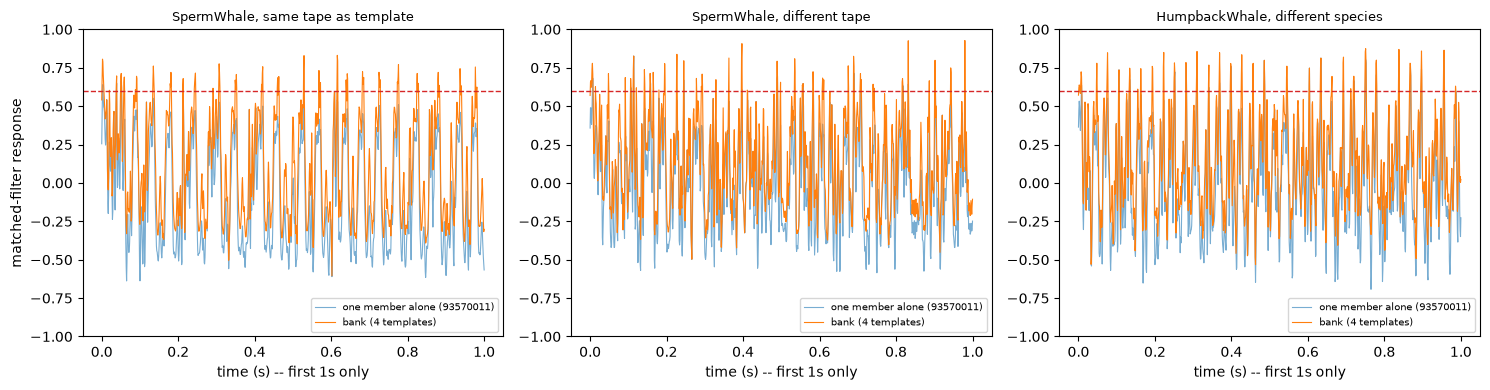

In [8]:
BANK_RECORDS = ["93570011", "72009005", "9357300H", "9358400V"]  # four different tapes

template_bank = []
for rec in BANK_RECORDS:
    clip = by_record[rec]
    y_b, sr_b = sf.read(clip.path)
    env_b, rate_b = demon_envelope(torch.from_numpy(y_b.astype(np.float32)).unsqueeze(0),
                                   sample_rate=sr_b)
    template_bank.append(average_pulse_template(env_b, rate_b))

print("bank:   " + ",  ".join(f"{r} (tape {by_record[r].tape_id})" for r in BANK_RECORDS))
print("tested: " + ",  ".join(f"{c.record_number} (tape {c.tape_id})" for _, c in test_clips))

# How different are the members actually? Mean-removed, unit-norm correlation
# between every pair -- near-duplicates would add chances to fire but no new
# shapes, and the bank would be pure false-alarm inflation.
stack = torch.stack([(t - t.mean()) / (t - t.mean()).norm() for t in template_bank])
pairwise = (stack @ stack.T)[~torch.eye(len(template_bank), dtype=bool)]
print(f"\npairwise template correlation: {pairwise.min():.2f}-{pairwise.max():.2f} "
      f"(mean {pairwise.mean():.2f})")

# CV of detection gaps (lower = more metronomic) and the share of detections
# on a real pulse (higher = less noise-chasing), for every member alone and
# then for the bank.
columns = [r[-4:] for r in BANK_RECORDS] + ["BANK"]
header = f"{'test clip':34s}" + "".join(f"{c:>14s}" for c in columns)
print("\n" + header)
print("-" * len(header))
responses = {}
for label, clip in test_clips:
    y_c, sr_c = sf.read(clip.path)
    w = torch.from_numpy(y_c.astype(np.float32)).unsqueeze(0)
    env, rate = demon_envelope(w, sample_rate=sr_c)

    scored = [score(env, matched_filter(env.unsqueeze(0), tmpl), rate)
              for tmpl in template_bank]
    bank_response = matched_filter_bank(env.unsqueeze(0), template_bank)
    scored.append(score(env, bank_response, rate))

    # A guarded cell prints its detection count, not a number: too few
    # detections to estimate either statistic. Printing "nan" invites the
    # reader to treat it as a bad score rather than an absent one.
    cells = [f"{s.cv:8.2f} {s.on_pulse:4.0%}" if s.note is None
             else f"{'n=' + str(s.n):>8s} {'--':>4s}"
             for s in scored]

    responses[label] = (env, rate, matched_filter(env.unsqueeze(0), template_bank[0]), bank_response)
    print(f"{label:34s}" + "".join(cells))
print("\n(each cell: CV of detection gaps, then % of detections on a real pulse;")
print(f" 'n=..' means fewer than {MIN_DETECTIONS} detections -- neither is estimable)")

fig, axes = plt.subplots(1, len(test_clips), figsize=(15, 4))
for ax, (label, clip) in zip(axes, test_clips):
    env, rate, single_response, bank_response = responses[label]
    t_axis = np.arange(len(bank_response)) / rate
    zoom = t_axis <= ZOOM_S
    ax.plot(t_axis[zoom], single_response.numpy()[zoom], alpha=0.6, linewidth=0.8,
            label=f"one member alone ({BANK_RECORDS[0]})")
    ax.plot(t_axis[zoom], bank_response.numpy()[zoom], linewidth=0.8,
            label=f"bank ({len(template_bank)} templates)")
    ax.axhline(DETECTION_THRESHOLD, color="tab:red", linestyle="--", linewidth=1)
    ax.set_title(label, fontsize=9)
    ax.set_xlabel(f"time (s) -- first {ZOOM_S:g}s only")
    ax.set_ylim(-1, 1)
    ax.legend(fontsize=7, loc="lower right")
axes[0].set_ylabel("matched-filter response")
plt.tight_layout()
plt.show()


The bank's response is never *below* any member's -- it is an elementwise
max, so it can only tie or beat them. What the table shows is subtler
than "more templates is better", and it is worth reading all three rows.

**The bank's real value is removing the gamble.** On the first
SpermWhale clip the members alone score CV 0.29, 0.94 and 1.14 -- one is
an excellent detector, two are worse than the humpback clip scores -- and
the fourth (`93570011`) does not score at all: it fired only 13 times,
below `pulse_train_stats`' 20-detection floor, so the function returns
NaN instead of a number. Four SpermWhale click trains off comparable
tapes, and nothing distinguishes them in advance. The bank lands on 0.29
with 73 detections: it tracks its best member without you having had to
know which one that was. That is variance reduction, and it is most of
what a filter bank buys in practice -- the direct answer to section 6's
finding that you cannot pick a good template by inspection.

(The `nan` in that column is the guard doing its job on this notebook's
own table. An earlier version printed 1.30 there, computed from those 13
detections, and it read as just another mediocre score. Both statistics
below are averages over the detections and both drift optimistic as the
count falls, so a number from 13 of them is not comparable with one from
73 -- see `pulse_train_stats` for the measurement behind the threshold.)

**And it gets there from four foreign tapes.** No bank member shares a
tape with the first test clip, yet the bank scores CV 0.29 with 75% of
detections on real pulses -- close to the 0.20/91% that section 6's
template, from that clip's own tape, managed. Nothing about the bank's
recording conditions matches the clip's; four clips' worth of shape
diversity was enough on its own. That is the most encouraging thing in
this section, and it is consistent with section 6's control: what makes
a template work is the quality of the click trains inside it, not whose
tape it came from.

**But the gap between click train and not-a-click-train does not
widen.** The humpback's CV also drops, to 0.63, better than any
individual member. More templates means more chances to fire, and a
denser set of false detections is a more evenly spaced one. Reliability
improved; separability did not.

**And one number improving does not mean the detector improved.** On the
different-tape SpermWhale clip the bank posts the best CV in the row
(0.45) together with the *worst* on-pulse fraction (12%). It became more
regular by chasing the noise floor more consistently, not by finding
clicks. Had we reported CV alone -- the obvious single headline number --
that row would read as the bank's best result instead of its emptiest.
Keeping a second, differently-motivated metric alongside the first is
what catches this, and the same discipline is why notebook 05 reports
macro-F1 next to accuracy rather than instead of it.

Note finally how much work the *statistic* does rather than the filter.
The number separating these clips is the regularity of detection
spacing, which is the periodicity DEMON measured in section 5 -- and the
pulse rates the matched filter reports for the SpermWhale clips agree
with section 5's ~20.5Hz peak, from an unrelated computation. Two
independent routes to the same number is a far stronger claim than
either alone. A deployment-grade detector adds considerably more on top
(FFT/GCC-PHAT correlation, CFAR thresholding, whitening); see the next
slide in `docs/theory-deck`.

## Exercises

1. The default config uses 64 mel bins. Try 32 and 128 -- inspect the
   resulting spectrogram images. At what point does more resolution stop
   visibly helping for a 3-4 second clip like this?
2. Zoom the LOFARgram plot into 0-1kHz for the humpback clip. Can you
   count distinct harmonic lines? Roughly estimate their frequency
   spacing.
3. `f_max` in `LogMelSpectrogram` defaults to the Nyquist frequency
   (8kHz for 16kHz audio). Given that odontocete clicks/whistles often
   extend past that ceiling (see `features.py`'s module docstring), what
   is this pipeline definitely *not* able to see for those species?
4. Re-run the DEMON comparison on a couple more echolocating species
   (e.g. `BottlenoseDolphin`, id 14, or `KillerWhale`, id 22 -- orcas both
   echolocate and produce tonal calls). Play the clip and look at the
   envelope panel *before* you trust the peak: most clips you pick at
   random will not contain a usable click train, and the peak you get
   from one of those is noise. For the clips that do, do their
   click-repetition-rate peaks land at noticeably different frequencies
   from the sperm whale's? A real difference here would be a genuinely
   useful hand-engineered feature for a classifier.
5. Reproduce section 6's control, then push on it. Build one template,
   score every SpermWhale clip you can, and split the CV/on-pulse results
   by whether the clip shares the template's tape -- you should find the
   same-tape group ahead. Then swap in a template from another tape and
   re-score: the advantage should largely evaporate, because it was mostly
   "that tape has cleaner click trains", not "the template matches that
   tape". Two traps to avoid, both of which will manufacture a tape effect
   that isn't there: filtering clips by on-pulse fraction before comparing
   (it removes the cross-tape failures preferentially), and comparing the
   best-N of each group when the groups are wildly different sizes.
   Extension: if tape identity doesn't predict a good template, what does?
   Try ranking candidate templates by their own clip's DEMON peak
   prominence and see whether that predicts how well they score elsewhere.
6. Grow the bank from 4 templates to 8-10, still one per tape. Section 7
   found the bank tracking its best member while the click/not-click gap
   stayed flat. Does that hold at 10, or does the humpback's CV keep
   falling until the two are indistinguishable?
7. `DETECTION_THRESHOLD` (0.6) and `detect_peaks`'s `refractory_s`
   (15ms) were fixed by hand. Sweep the threshold from 0.3 to 0.9 and
   plot CV and on-pulse fraction against it for a SpermWhale clip and
   the HumpbackWhale clip. Is there a threshold where the curves cross --
   and would you have found 0.6 without already knowing the answer?
   (Real detectors set this from a false-alarm rate measured on
   noise-only data: CFAR.)
8. The refractory period caps the reportable rate at 1/`refractory_s` =
   66Hz. Several dolphin species click far faster than that in a
   terminal buzz. Pick a `CommonDolphin` (id 36) clip with a high DEMON
   peak, and see what the detector reports before and after you shorten
   the refractory period to match.
9. `average_pulse_template` averages the envelope. Try averaging the
   log-envelope instead, or the envelope normalized per pulse, so loud
   near clicks don't dominate the mean. Does the cross-tape on-pulse
   fraction improve?
10. Try a bank from a *different* species with more tapes available (see
    `docs/class_reference.md`) and cross-test against several other
    species, not just one. Does anything here hold up, or was the sperm
    whale/humpback pair an easy case?